In [1]:
using LinearAlgebra
using QuantumToolbox
using CairoMakie

In [14]:
const Sub_divisions = 32
const count_iterations = 1024
const ω01 = 6.063 * 1000 #MHz
const ωpulse = 6.06 * 1000 #MHz
const precession = 1/(ω01 - ωpulse) # Nanoseconds
const time_to_iter = 2 * Sub_divisions * 1/(precession)
const tolerance = 0.995
const step_size = 4
const side_tolerance = 0.1

initial_state = ComplexF64[1;0]
H_Gate = ComplexF64[1/√2 1/√2; 1/√2 -1/√2]
T_gate = ComplexF64[1 0; 0 exp(im*π/Sub_divisions)]
rot_90 = ComplexF64[1/√2 -1/√2; 1/√2 1/√2]

function measure(vec)
    if abs2(vec[1]) > rand()
        vec[1] = 1
        vec[2] = 0
        return 0
        end
    vec[1] = 0
    vec[2] = 1
    return 1
end

function ramsey(t)
    return measure(rot_90 * T_gate ^ t * rot_90 * initial_state)
end

function count(n, t)
    count = 0
    for i in range(1,n)
        measured = ramsey(t)
        if measured == 1
            count += 1
        end
    end
    return count
end

function operate(time)
    iter = time * time_to_iter
    t_range = range(1, iter)
    data = []
    probs = []
    for i in t_range
        counted = count(count_iterations, i)
        push!(data, counted)
        push!(probs, counted/count_iterations)
    end

    Ts = convert_time(range(1, iter))

    return [data, probs, Ts]
end

operate(2)

3-element Vector{Vector{Any}}:
 [1022, 1013, 1000, 984, 972, 943, 909, 862, 839, 810  …  839, 857, 896, 945, 969, 991, 1006, 1019, 1023, 1024]
 [0.998046875, 0.9892578125, 0.9765625, 0.9609375, 0.94921875, 0.9208984375, 0.8876953125, 0.841796875, 0.8193359375, 0.791015625  …  0.8193359375, 0.8369140625, 0.875, 0.9228515625, 0.9462890625, 0.9677734375, 0.982421875, 0.9951171875, 0.9990234375, 1.0]
 [0.005208333333333333, 0.010416666666666666, 0.015625, 0.020833333333333332, 0.026041666666666664, 0.03125, 0.03645833333333333, 0.041666666666666664, 0.046875, 0.05208333333333333  …  1.953125, 1.9583333333333333, 1.9635416666666665, 1.96875, 1.9739583333333333, 1.9791666666666665, 1.984375, 1.9895833333333333, 1.9947916666666665, 2.0]

In [3]:
function convert_time(lst)
    conv = []
    for i in lst
        push!(conv, i * precession/(2 * Sub_divisions))
    end
    return conv
end

convert_time (generic function with 1 method)

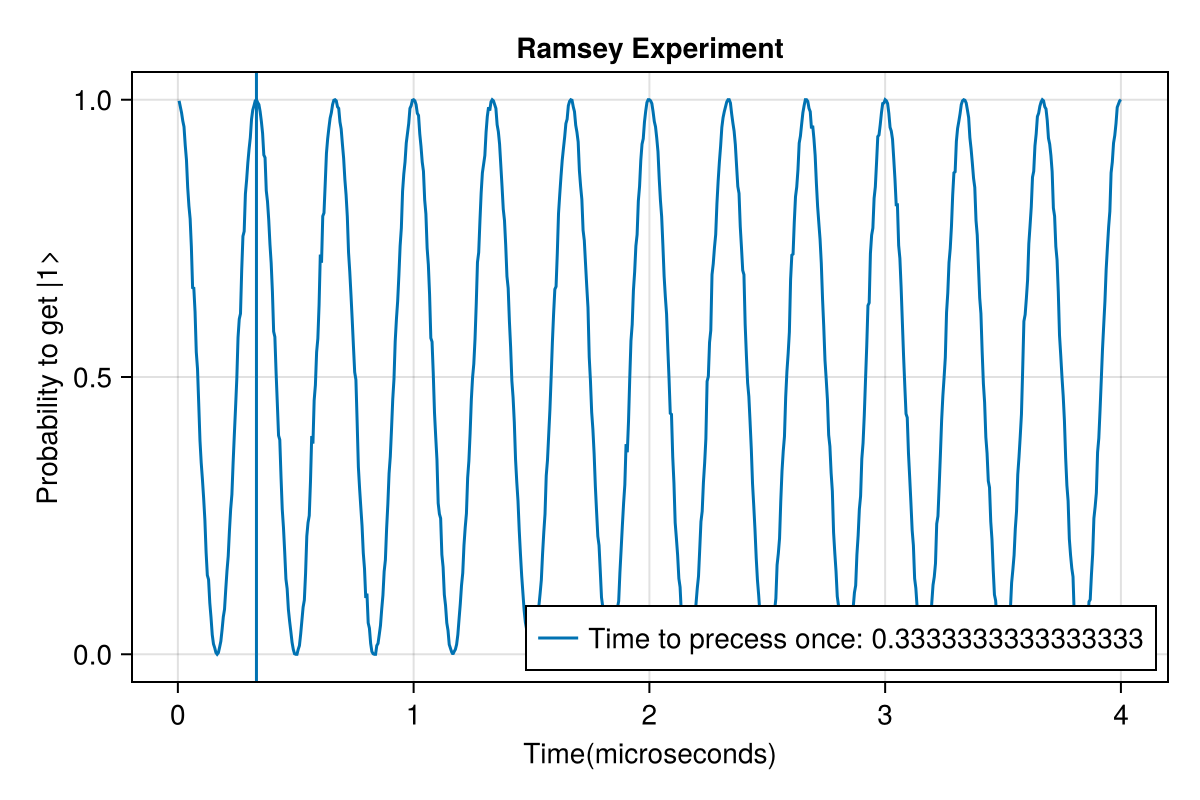

CairoMakie.Screen{IMAGE}


In [6]:
g = operate(4)

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
vlines!(ax, precession, label = "Time to precess once: $(precession)")
lines!(ax, g[3], g[2])
axislegend(ax; position = :rb)
display(fig)

In [7]:
function calculate_ramsey_period(time; tol = tolerance)
    lst = operate(time)[2]
    period = []
    if lst[1]>tol
        push!(period, 1)
    end
    if lst[end]>tol
        push!(period, length(lst))
    end
    for i in range(1,length(lst); step = step_size)
        if i > step_size  && i < length(lst) - (step_size+1)
            if lst[i]>tol
                push!(period, i)
            end
        end
    end
    sort!(period)
    return [period, (period[length(period)] - period[1])/length(period)]
end


function calc_multi_period(time; tol = tolerance)
    periods = []
    for i in range(1,10)
        push!(periods, calculate_ramsey_period(time)[2])
    end
    return [periods, maximum(periods), sum(periods)/length(periods)]
end


function find_time_periods(time; tol = tolerance)
    time_period = []
    for i in range(1, 10)
        periods = convert_time(calculate_ramsey_period(time)[1]) 
        for j in range(1, length(periods))
            if periods[j] ∉ time_period
                push!(time_period, periods[j])
            end
        end
    end
    sort!(time_period)
    return time_period
end

function trim_time_periods(time, side_tol; tol = tolerance)
    time_period_init = find_time_periods(time)
    time_period = copy(time_period_init)
    for i in range(1,length(time_period) - 2)
        if (time_period[i+1] - time_period[i]) < side_tol
            time_period[i] = (time_period[i+1] + time_period[i])/2
            deleteat!(time_period, i+1) 
        end
    end
    return [time_period_init, time_period]
end

trim_time_periods (generic function with 1 method)

In [8]:
function calc_time_period(time, side_tol; tol = tolerance)
    peaks =  trim_time_periods(time, side_tol)[2]
    periods = []
    for i in range(1, length(peaks) - 2)
        push!(periods, peaks[i+1] - peaks[i])
    end
    period = sum(periods)/length(periods)
    return [peaks, periods, period, 1/period]
end

calc_time_period (generic function with 1 method)

In [10]:
calc = calc_time_period(20, side_tolerance)

4-element Vector{Any}:
  Any[0.005208333333333333, 0.33854166666666663, 0.671875, 1.0052083333333333, 1.3385416666666665, 1.671875, 2.005208333333333, 2.3385416666666665, 2.671875, 3.005208333333333  …  17.005208333333332, 17.338541666666664, 17.671875, 18.005208333333332, 18.338541666666664, 18.671875, 19.005208333333332, 19.338541666666664, 19.671875, 20.0]
  Any[0.3333333333333333, 0.33333333333333337, 0.33333333333333326, 0.33333333333333326, 0.3333333333333335, 0.33333333333333304, 0.3333333333333335, 0.3333333333333335, 0.33333333333333304, 0.3333333333333335  …  0.3333333333333357, 0.33333333333333215, 0.33333333333333215, 0.3333333333333357, 0.33333333333333215, 0.33333333333333215, 0.3333333333333357, 0.33333333333333215, 0.33333333333333215, 0.3333333333333357]
 0.3333333333333333
 3.0

In [11]:
Ts = operate(30)[3]
Δ = calc[4]
A = 0.5
C = 0.5
T1 = 15 * 1000 #Microseconds(1000x nanoseconds)
Tϕ = 10^3 * 1000 #Microseconds(1000x nanoseconds)
T2x = (1/2T1 + 1/Tϕ)^-1/1000

function P(t, A, C)
    return A * exp(-t/T2x) * cos(2π * Δ * t) + C
end
decaying = []
border = []
for i in Ts
    push!(decaying, P(i, A, C))
    push!(border, A * exp(-i/T2x) + C)
end

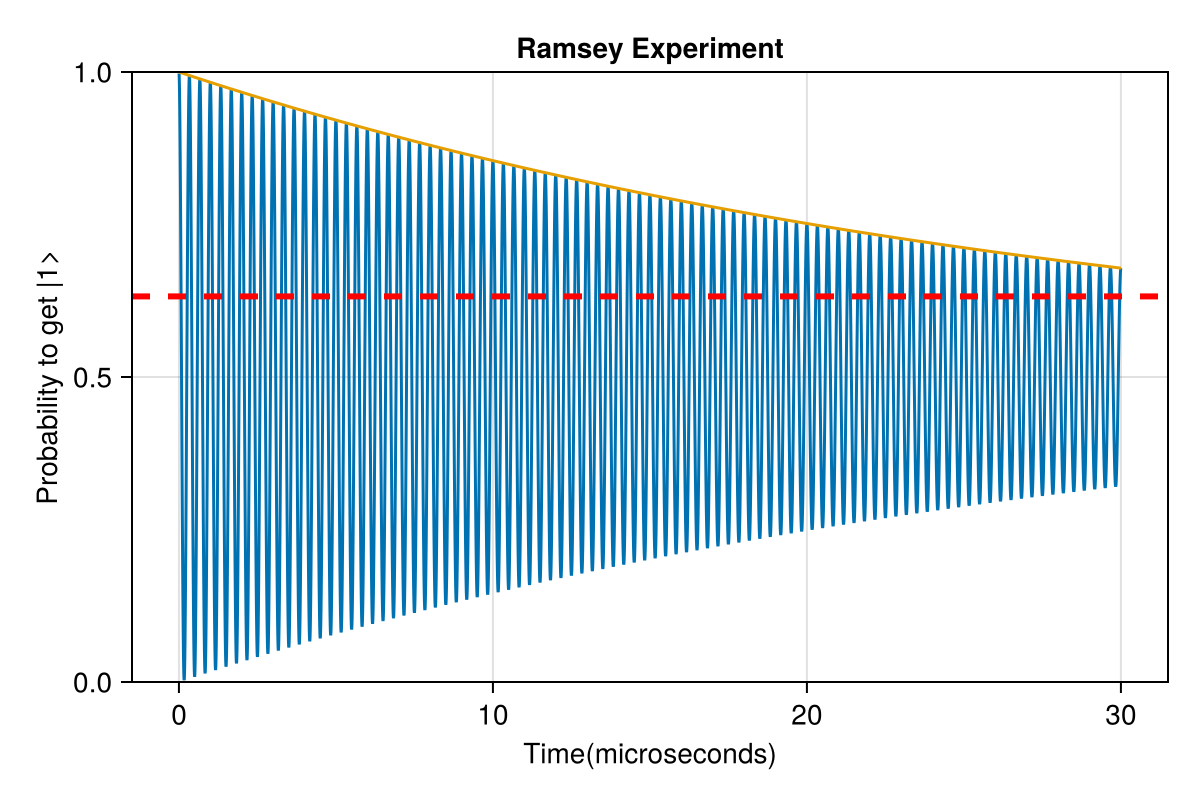

CairoMakie.Screen{IMAGE}


In [12]:
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, Ts, decaying)
lines!(ax, Ts, border)
hlines!(ax, 1-1/ℯ, linewidth = 3, color = :red, linestyle = :dash)
ylims!(ax, (0.0, 1.0))
display(fig)

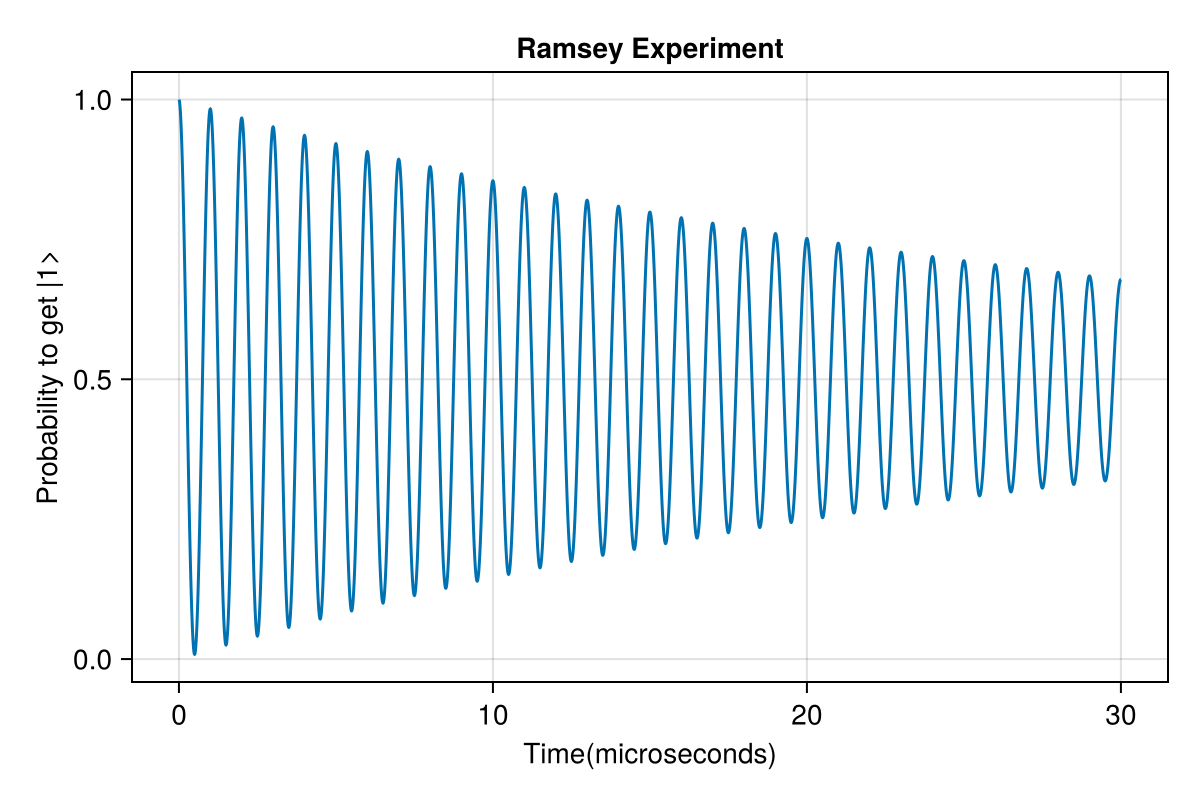

CairoMakie.Screen{IMAGE}


In [13]:
T1 = 15 * 1000 #Microseconds(1000x nanoseconds)
Tϕ = 10^3 * 1000 #Microseconds(1000x nanoseconds)
T2x = (1/2T1 + 1/Tϕ)^-1/1000
function Probability_Ramsey(Δ, time)
    Ts = operate(time)[3]    
    function P(t)
        return 0.5 * exp(-t/T2x) * cos(2π * Δ * t) + 0.5
    end
    decaying = []
    for i in Ts
        push!(decaying, P(i))
    end

    return [Ts, decaying]
end

Δf = 1 #MHz
t = 30
Decay = Probability_Ramsey(Δf, t)
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, Decay[1], Decay[2] )
display(fig)